# 📌 Chest X-Ray Classification using Deep Learning

This notebook demonstrates building and training a deep learning model for **Chest X-Ray image classification**.  
The workflow includes data preprocessing, visualization, model construction, training, and evaluation.

---

## 📌 Project Overview
This project applies **Deep Learning** to classify chest X-ray images into two classes:  
- **Pneumonia** 🫁  
- **Normal** ✅  

We leverage **CNN** to achieve high accuracy while reducing training time.

---

## 1. 📚 Import Libraries
We start by importing the necessary libraries for data handling, visualization, and deep learning.

---

In [1]:
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.utils import shuffle           
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax
from sklearn.model_selection import train_test_split 
from tensorflow.keras.applications import ResNet50
from keras import Sequential
from keras.layers import *
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.python.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm
import warnings 
warnings.filterwarnings("ignore")

2025-09-23 16:48:19.400700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758646099.751879      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758646099.848191      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



## 2. ⚙️ Constants and Parameters
Define constants such as image size, batch size, number of epochs, etc.

---

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 1
IMAGE_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)
LOSS_OPTIMIZER = 'binary_crossentropy'
METRICS='accuracy'

## 3. 📂 Load Dataset
Load the Chest X-Ray dataset for training , testing and validation.

---

In [3]:
class_names = os.listdir('/kaggle/input/chest-xray-pneumonia/chest_xray/test')
class_names.reverse()
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

class_names, class_names_label

(['NORMAL', 'PNEUMONIA'], {'NORMAL': 0, 'PNEUMONIA': 1})

In [4]:
path = '/kaggle/input/chest-xray-pneumonia/chest_xray/'
splits = ["train", "val", "test"]

def load_data():
    
    df_all = pd.DataFrame(columns = ['image_path', 'label'])
    
    # Iterate through training and test sets
    for split in splits:
        
        images_path = []
        label = []
        
        print("Loading {}".format(split))
        
        # Iterate through each folder corresponding to a category
        root = os.path.join(path, split)
        for folder in os.listdir(root):
            
            # Iterate through each image in our folder
            
            for file in tqdm(os.listdir(os.path.join(root, folder))):
                images_path.append(os.path.join(os.path.join(root, folder), file))
                label.append(folder)  
        
        df_conc = pd.DataFrame({
                "image_path": images_path,
                "label": label
            })
        df_all = pd.concat([df_conc, df_all], ignore_index=True)

    return df_all

In [5]:
df_all = load_data()
df_all

Loading train


100%|██████████| 1341/1341 [00:00<00:00, 566763.57it/s]


Loading val


100%|██████████| 8/8 [00:00<00:00, 61342.65it/s]


Loading test


100%|██████████| 234/234 [00:00<00:00, 360966.21it/s]


,image_path,label
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
...,...,...
5851,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5852,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5853,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5854,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL


## 4. 🖼️ Display Sample Images
Visualize random images from the dataset to get a sense of the data.

---

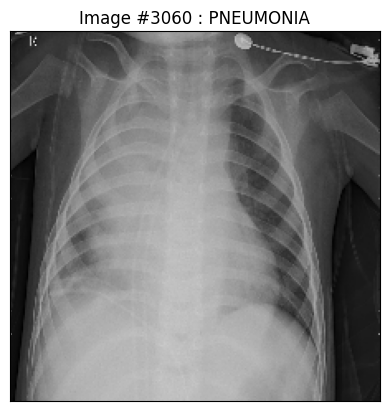

In [6]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """
    
    images = images.to_numpy()
    labels = labels.to_numpy()
    
    index = np.random.randint(len(images))
    plt.figure()
    
    img = cv2.imread(images[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE) 
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f"Image #{index} : {labels[index]}")
    plt.show()

display_random_image(class_names, df_all['image_path'], df_all['label'])

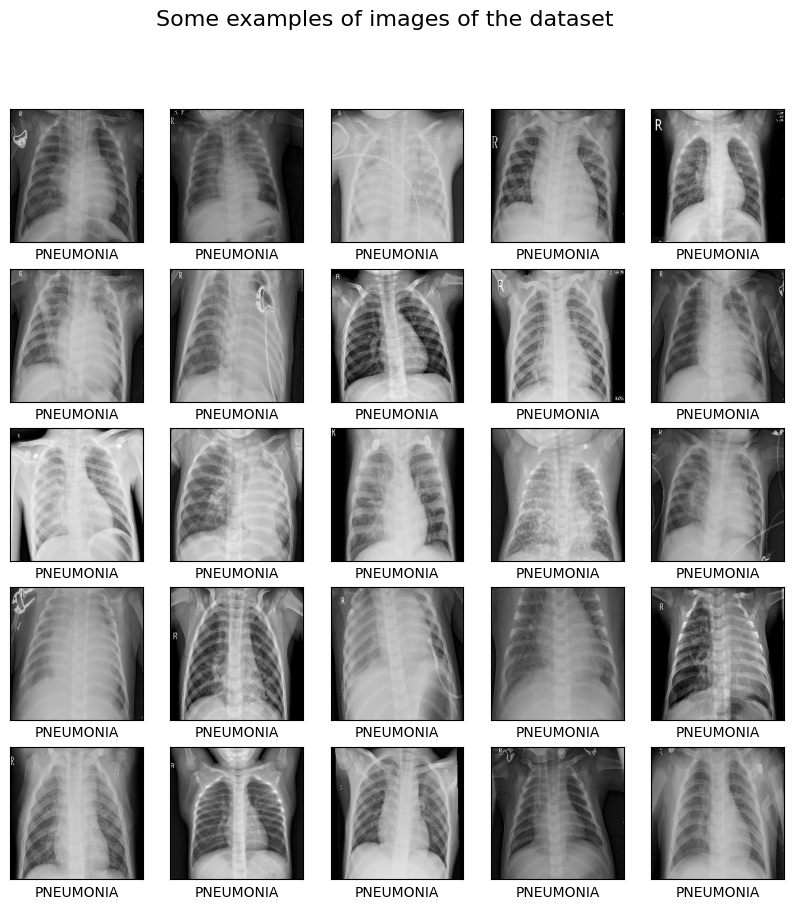

In [7]:
def display_examples(class_names, images, labels):
    """
        Display 25 random images from the images array with its corresponding labels
    """
    
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        img = cv2.imread(images[i + random.choice(range(images.shape[0])) - 25])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SIZE)
        plt.imshow(img)
        plt.xlabel(labels[i])
    plt.show()

display_examples(class_names, df_all['image_path'], df_all['label'])

## 5. ✂️ Train / Validation / Test Split
Split the dataset into training, validation, and testing subsets.

---

In [8]:
df_train, df_test = train_test_split(
    df_all,
    test_size=0.1,
    stratify=df_all["label"],
    random_state=42
)

df_train, df_val = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train["label"],
    random_state=42
)

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

Train size: 4743
Val size: 527
Test size: 586


## 6. 📊 Data Visualization
Explore the dataset distribution and visualize class balance.

---

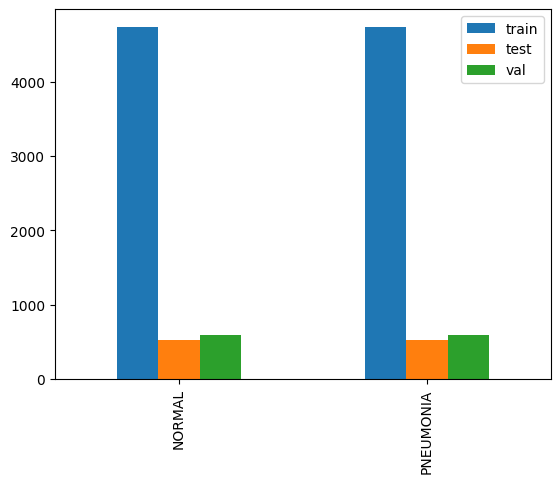

In [9]:
pd.DataFrame({'train': len(df_train),
                    'test': len(df_val),
             'val': len(df_test)}, 
             index=class_names
            ).plot.bar()
plt.show()

In [10]:
def Pie_chart(data):
    plt.pie(data['label'].value_counts(),
            labels=class_names,
            autopct='%1.1f%%')
    plt.axis('equal')
    plt.title('Proportion of each observed category')
    plt.show()

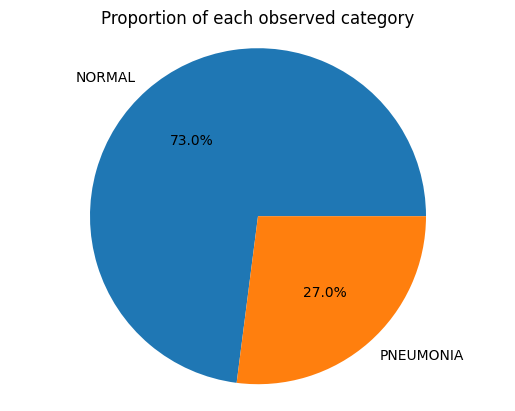

In [11]:
Pie_chart(df_train)

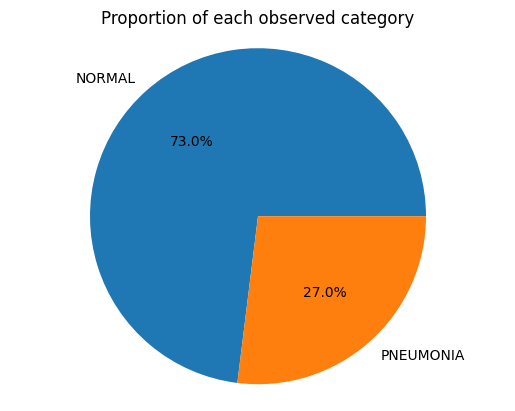

In [12]:
Pie_chart(df_test)

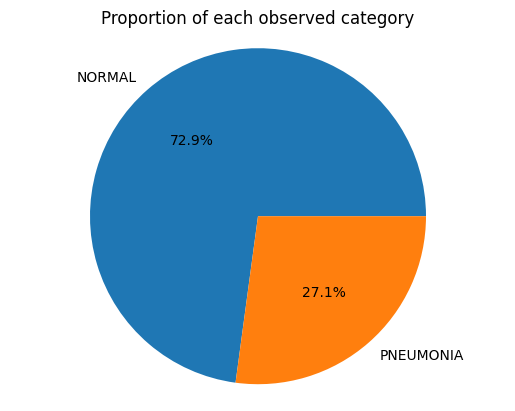

In [13]:
Pie_chart(df_val)

## 7. 🔄 Data Augmentation
Apply augmentation (rotation, flipping, scaling, etc.) to improve model generalization.

---

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=5,
    width_shift_range=0.01,
    height_shift_range=0.01,
    shear_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="constant",         
    cval=0
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = train_datagen.flow_from_dataframe(
    dataframe = df_train,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "grayscale",  
    class_mode = "binary",
    shuffle = True,
    batch_size = BATCH_SIZE,
    seed = 42
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe = df_val,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "grayscale",  
    class_mode = "binary",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)
test_gen = val_datagen.flow_from_dataframe(
    dataframe = df_test,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "grayscale",  
    class_mode = "binary",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)

Found 4743 validated image filenames belonging to 2 classes.
Found 527 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.


In [15]:
print("Train class indices:", train_gen.class_indices)
print("Val class indices:", val_gen.class_indices)
print("Test class indices:", test_gen.class_indices)

Train class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Val class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Test class indices: {'NORMAL': 0, 'PNEUMONIA': 1}



## 🏗️ CNN Model Architecture

The CNN model was built from scratch with the following layers:

1. **Input Layer**:  
   - Input shape: `(224, 224, 3)` (resized X-Ray images)

2. **Convolution + Pooling Blocks**:  
   - **Conv2D (32 filters, 3×3, ReLU)** → **MaxPooling2D (2×2)**  
   - **Conv2D (64 filters, 3×3, ReLU)** → **MaxPooling2D (2×2)**  
   - **Conv2D (128 filters, 3×3, ReLU)** → **MaxPooling2D (2×2)**  

3. **Flatten Layer**:  
   - Converts 2D feature maps into a 1D vector.

4. **Fully Connected Layers**:  
   - Dense layer with **64 neurons, ReLU activation**  
   - Dense layer with **128 neurons, ReLU activation**  
   - Dense layer with **256 neurons, ReLU activation**  
   - Dense layer with **256 neurons, ReLU activation**  
   - Dense layer with **64 neurons, ReLU activation**  

5. **Output Layer**:  
   - Dense layer with **number of classes (e.g., 2 for Normal vs Pneumonia)**  
   - Sigmoid activation for multi-class classification

---

### 🔑 Notes:
- Optimizer: **Adam**  
- Loss Function: **binary_crossentropy** 
- Metrics: **Accuracy**

---

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = IMAGE_SHAPE),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    
    tf.keras.layers.Dense(1, activation=tf.nn.sigmoid)
])

I0000 00:00:1758646128.167448      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758646128.168129      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 9. ⚡ Compile & Model Summary
Compile the CNN model with optimizer, loss function, and metrics. Display the architecture summary.

---

In [17]:
model.summary()
model.compile(optimizer = 'adam', loss = LOSS_OPTIMIZER, metrics=[METRICS])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,754,177 (21.95 MB)

 Trainable params: 5,754,177 (21.95 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=10,          
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1)
check_point = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",      
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

## 10. 🚀 Train the Model
Fit the CNN model on the training set and validate on the validation set.

---

In [19]:
history = model.fit(train_gen,
                    epochs=30,
                    validation_data=val_gen,
                    callbacks=[early_stopping, check_point],
                    )

Epoch 1/30


I0000 00:00:1758646135.036144      67 service.cc:148] XLA service 0x78a0a80019b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758646135.037979      67 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758646135.038006      67 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758646135.634580      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/149 ━━━━━━━━━━━━━━━━━━━━ 24:41 10s/step - accuracy: 0.7500 - loss: 0.6914

I0000 00:00:1758646140.888090      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7631 - loss: 0.5347
Epoch 1: val_accuracy improved from -inf to 0.83871, saving model to best_model.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 90s 538ms/step - accuracy: 0.7634 - loss: 0.5339 - val_accuracy: 0.8387 - val_loss: 0.3943
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9012 - loss: 0.2618
Epoch 2: val_accuracy improved from 0.83871 to 0.93548, saving model to best_model.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.9013 - loss: 0.2616 - val_accuracy: 0.9355 - val_loss: 0.1510
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9109 - loss: 0.2241
Epoch 3: val_accuracy did not improve from 0.93548
149/149 ━━━━━━━━━━━━━━━━━━━━ 47s 316ms/step - accuracy: 0.9110 - loss: 0.2240 - val_accuracy: 0.9336 - val_loss: 0.1705
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9278 - loss: 0.1899
Epoch 4: val_accuracy improved from 0.93548 to 0.96015, saving model to best_mo

## 11. ✅ Evaluation
Evaluate the trained CNN on the test dataset.

---

In [20]:
print("Train class evaluate :", model.evaluate(train_gen))
print("Val class evaluate :", model.evaluate(val_gen))
print("Test class evaluate :", model.evaluate(test_gen))

149/149 ━━━━━━━━━━━━━━━━━━━━ 45s 303ms/step - accuracy: 0.9625 - loss: 0.1005
Train class evaluate : [0.10287747532129288, 0.9616276621818542]
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.9766 - loss: 0.0805
Val class evaluate : [0.07713060826063156, 0.9753320813179016]
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 391ms/step - accuracy: 0.9461 - loss: 0.1349
Test class evaluate : [0.12085802108049393, 0.9488054513931274]


## 12. 📈 Training Curves
Plot the accuracy and loss curves for both training and validation sets.

---

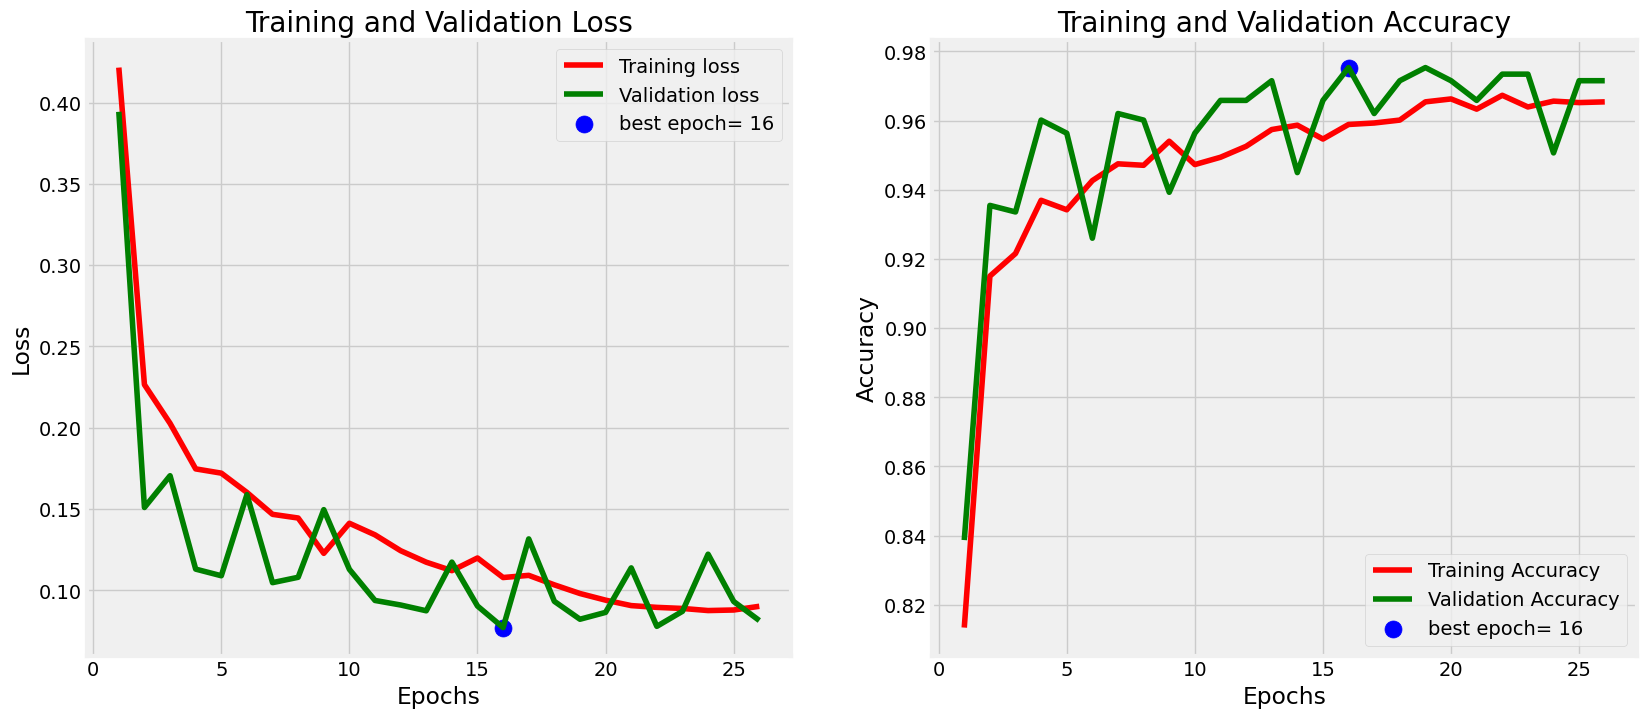

In [21]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'


plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, train_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [22]:
test_predict_prob = model.predict(test_gen)
test_predict_prob

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step


array([[9.99997497e-01],
       [8.48302722e-01],
       [1.66410655e-01],
       [8.07319105e-01],
       [9.99905705e-01],
       [9.96888101e-01],
       [9.95289683e-01],
       [9.99800980e-01],
       [9.45440471e-01],
       [9.86692250e-01],
       [9.99725759e-01],
       [1.42560410e-03],
       [2.21201763e-01],
       [9.99793470e-01],
       [9.56597149e-01],
       [8.33441615e-01],
       [6.87277138e-01],
       [5.86900394e-03],
       [8.18377256e-01],
       [3.04204285e-01],
       [9.82288241e-01],
       [9.31173027e-01],
       [9.96645510e-01],
       [8.62616420e-01],
       [9.98601973e-01],
       [9.98699546e-01],
       [1.79047137e-02],
       [9.86488521e-01],
       [1.77020468e-02],
       [1.81160435e-01],
       [9.99997020e-01],
       [9.95939255e-01],
       [9.99896049e-01],
       [9.99976039e-01],
       [4.73657995e-03],
       [9.87682164e-01],
       [3.50114554e-01],
       [9.32198316e-02],
       [9.81333673e-01],
       [9.99998569e-01],


In [23]:
y_pred = (test_predict_prob >= 0.5).astype(int).ravel()
y_pred

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,

In [24]:
y_true = test_gen.classes
y_true 

[1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,


## 13. 🔍 Confusion Matrix
Plot the confusion matrix to analyze performance across classes.

---


Confusion Matrix is : 
 [[148  10]
 [ 20 408]]


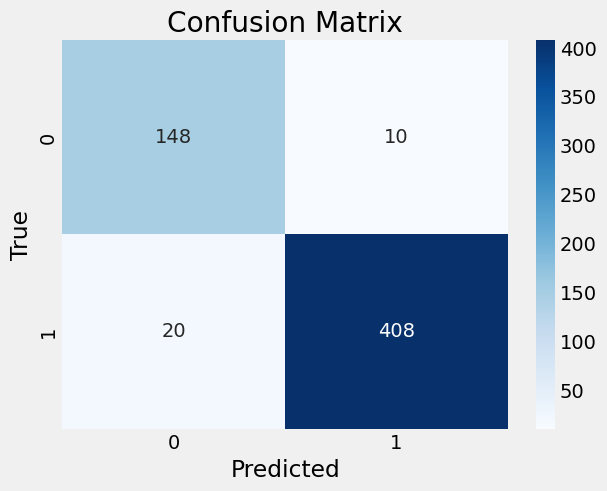

In [25]:
CM = confusion_matrix(y_true, y_pred)
print('Confusion Matrix is : \n', CM)

# drawing confusion matrix
sns.heatmap(CM, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## 14. 🖼️ Predictions vs True Labels
Display random test images along with predicted vs true labels.

---

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step


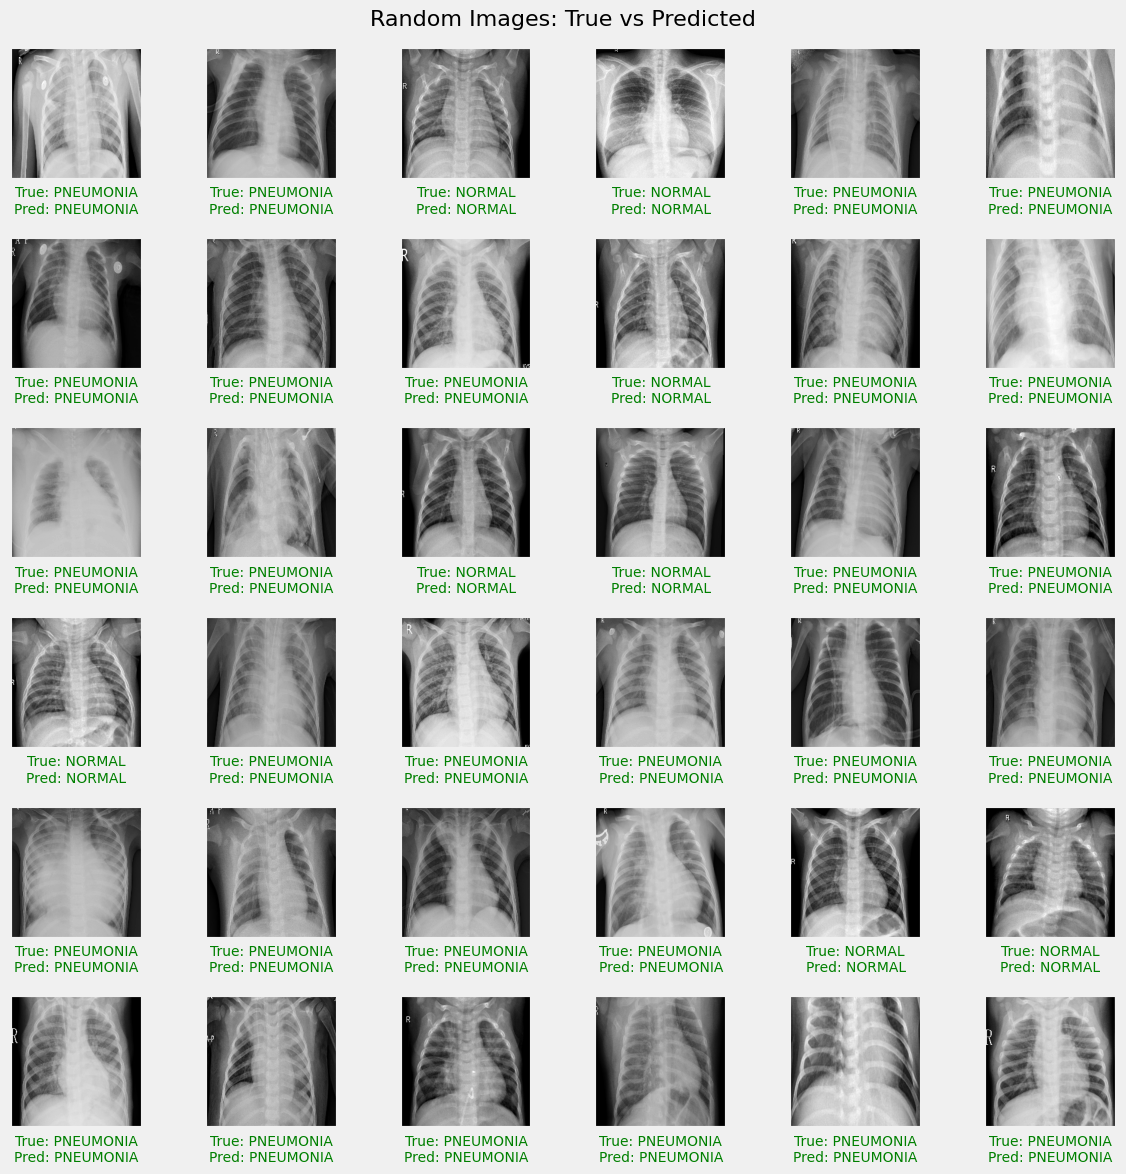

In [26]:
def display_predictions(model, class_names, images, labels, num_images=16, base_dir="dataset/images", image_size=(224,224)):
    """
    Display random images with their true and predicted labels.
    """

    images = images.to_numpy()
    labels = labels.to_numpy()

    indices = random.sample(range(len(images)), num_images)

    fig = plt.figure(figsize=(12,12))
    fig.suptitle("Random Images: True vs Predicted", fontsize=16)

    batch = []
    for idx in indices:
        img_path = os.path.join(base_dir, images[idx])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  
        img = cv2.resize(img, image_size)
        img = np.expand_dims(img, axis=-1) 
        batch.append(img)

    batch = np.array(batch) / 255.0

    # make predictions
    preds = model.predict(batch)
    if preds.shape[1] == 1:
        preds = (preds > 0.5).astype("int32").flatten()
    else:  
        preds = np.argmax(preds, axis=1)

    for i, idx in enumerate(indices):
        plt.subplot(int(np.sqrt(num_images)), int(np.sqrt(num_images)), i+1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(batch[i].squeeze(), cmap="gray")

        try:
            true_label = class_names[int(labels[idx])]
        except:
            true_label = labels[idx]
        pred_label = class_names[preds[i]]

        color = "green" if true_label == pred_label else "red"
        plt.xlabel(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

display_predictions(model, class_names, df_test['image_path'], df_test['label'], num_images=36)


# 🎯 Results & Conclusion
- Final Test Accuracy: **97.7%**
- The CNN model shows strong performance in classifying chest X-Ray images.  
- Possible future improvements:
  - Hyperparameter tuning  
  - Adding more layers/regularization  
  - Testing on external datasets for generalization